In [29]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')

MAPPE = Path('/home/ali/repos/porsche/budget_setting/highlight_budget_estimation/budget_setting_amendment/Mappe1.xlsx')
PREMIUM = Path('/home/ali/repos/porsche/budget_setting/highlight_budget_estimation/budget_setting_amendment/2024 JLR & Merc USD.xlsx')
USD_TO_EUR_2024 = 0.924

# -----------------------------
# A) VWG source (EUR)
# -----------------------------
raw = pd.read_excel(MAPPE, sheet_name='2024', header=6)
raw.columns = [str(c).strip() for c in raw.columns]

vwg = raw.rename(columns={
    'Brand': 'brand_raw',
    'Market': 'market',
    'Media': 'channel',
    'Sum of 2024 CY (EUR)': 'spend_eur'
})[['brand_raw', 'market', 'channel', 'spend_eur']]

for c in ['brand_raw', 'market', 'channel']:
    vwg[c] = vwg[c].astype(str).str.strip()
vwg['spend_eur'] = pd.to_numeric(vwg['spend_eur'], errors='coerce')
vwg = vwg[vwg['spend_eur'].notna() & (vwg['spend_eur'] > 0)].copy()

split = vwg['brand_raw'].str.extract(r'^(?P<brand>.*?)\s*-\s*Tier\s*(?P<tier>\d+)$')
vwg['brand'] = split['brand'].str.strip()
vwg['tier'] = pd.to_numeric(split['tier'], errors='coerce')

# Tier 1 only + remove helper rows
vwg = vwg[vwg['tier'] == 1].copy()
vwg = vwg[~vwg['brand_raw'].str.contains('Total|Grand Total', case=False, na=False)]
vwg = vwg[~vwg['market'].str.contains('Total', case=False, na=False)]

# keep requested VW brands only
vwg['brand_norm'] = vwg['brand'].str.strip().str.lower()
keep_map = {
    'porsche': 'PORSCHE',
    'audi': 'Audi',
    'vw brand': 'VW Brand',
    'bentley': 'Bentley',
    'cupra': 'CUPRA',
    'skoda': 'SKODA',
}
vwg = vwg[vwg['brand_norm'].isin(keep_map.keys())].copy()
vwg['brand'] = vwg['brand_norm'].map(keep_map)

# Keep only markets where Porsche exists
porsche_markets = sorted(vwg.loc[vwg['brand'].str.upper() == 'PORSCHE', 'market'].unique())
# Bentley books Tier-1 spend under "Bentley Central Campaigns" (not under USA/UK/etc.).
# A strict Porsche-market filter drops Bentley entirely — keep Bentley rows regardless.
vwg = vwg[
    vwg['market'].isin(porsche_markets)
    | (vwg['brand_norm'] == 'bentley')
].copy()

vwg = vwg[['brand', 'market', 'channel', 'spend_eur']].copy()

# -----------------------------
# B) Premium source (USD -> EUR)
# -----------------------------
prem = pd.read_excel(PREMIUM, sheet_name='2024 JLR & Merc USD')
prem.columns = [str(c).strip() for c in prem.columns]

prem = prem.rename(columns={
    'Client': 'client',
    'Market Cleaned': 'market',
    'Media Cleaned': 'channel',
    'Spend USD': 'spend_usd'
})[['client', 'market', 'channel', 'spend_usd']]

for c in ['client', 'market', 'channel']:
    prem[c] = prem[c].astype(str).str.strip()
prem['spend_usd'] = pd.to_numeric(prem['spend_usd'], errors='coerce').fillna(0)
prem = prem[prem['spend_usd'] > 0].copy()

# only JLR and Mercedes, as requested
prem = prem[prem['client'].isin(['JLR', 'Mercedes - Benz'])].copy()

# harmonize channel naming to sample taxonomy
prem['channel'] = prem['channel'].replace({
    'Prog. Display': 'Programmatic Display',
    'Prog. Video': 'Programmatic Video',
})

prem['spend_eur'] = prem['spend_usd'] * USD_TO_EUR_2024

# For plots 2 & 3: aggregate Premium Others as SUM
prem_sum = (
    prem.groupby(['market', 'channel'], as_index=False)['spend_eur']
    .sum()
)
prem_sum['brand'] = 'Premium Others'

# For plot 1 only: aggregate Premium Others as AVG (JLR vs Mercedes) by market
prem_avg_market = (
    prem.groupby(['market', 'client'], as_index=False)['spend_eur']
    .sum()
    .groupby('market', as_index=False)['spend_eur']
    .mean()
)
prem_avg_market['brand'] = 'Premium Others'

# -----------------------------
# C) Unified base table for plots 2/3
# -----------------------------
df = pd.concat(
    [
        vwg[['brand', 'market', 'channel', 'spend_eur']],
        prem_sum[['brand', 'market', 'channel', 'spend_eur']],
    ],
    ignore_index=True,
)

# Funnel mapping
stage_map = {
    'Search': 'LOWER',
    'Social': 'MIDDLE',
    'Display': 'MIDDLE',
    'Digital I/O': 'MIDDLE',
    'Other': 'MIDDLE',
    'Programmatic Display': 'MIDDLE',
    'Dig. Video': 'UPPER',
    'Video': 'UPPER',
    'Programmatic Video': 'UPPER',
    'TV': 'UPPER',
    'Print': 'UPPER',
    'OOH': 'UPPER',
    'Radio': 'UPPER',
    'Cinema': 'UPPER',
    'Unallocated': 'MIDDLE',
}

df['funnel_stage'] = df['channel'].map(stage_map).fillna('MIDDLE')

brands = ['PORSCHE', 'Audi', 'VW Brand', 'Bentley', 'CUPRA', 'SKODA', 'Premium Others']
all_markets = sorted(df['market'].unique())

main_markets = (
    df[df['brand'].str.upper() == 'PORSCHE']
    .groupby('market', as_index=False)['spend_eur'].sum()
    .sort_values('spend_eur', ascending=False)
    .head(5)['market']
    .tolist()
)

markets = main_markets
channels = sorted(df['channel'].unique())
stages = ['LOWER', 'MIDDLE', 'UPPER']

print('Rows (combined):', len(df))
print('Brands:', brands)
print('All markets:', len(all_markets))
print('Main markets used in market-split charts:', markets)
print('Channels:', len(channels))
print('Premium FX used (USD->EUR):', USD_TO_EUR_2024)


Rows (combined): 935
Brands: ['PORSCHE', 'Audi', 'VW Brand', 'Bentley', 'CUPRA', 'SKODA', 'Premium Others']
All markets: 44
Main markets used in market-split charts: ['USA', 'China', 'UK', 'Canada', 'Germany']
Channels: 13
Premium FX used (USD->EUR): 0.924


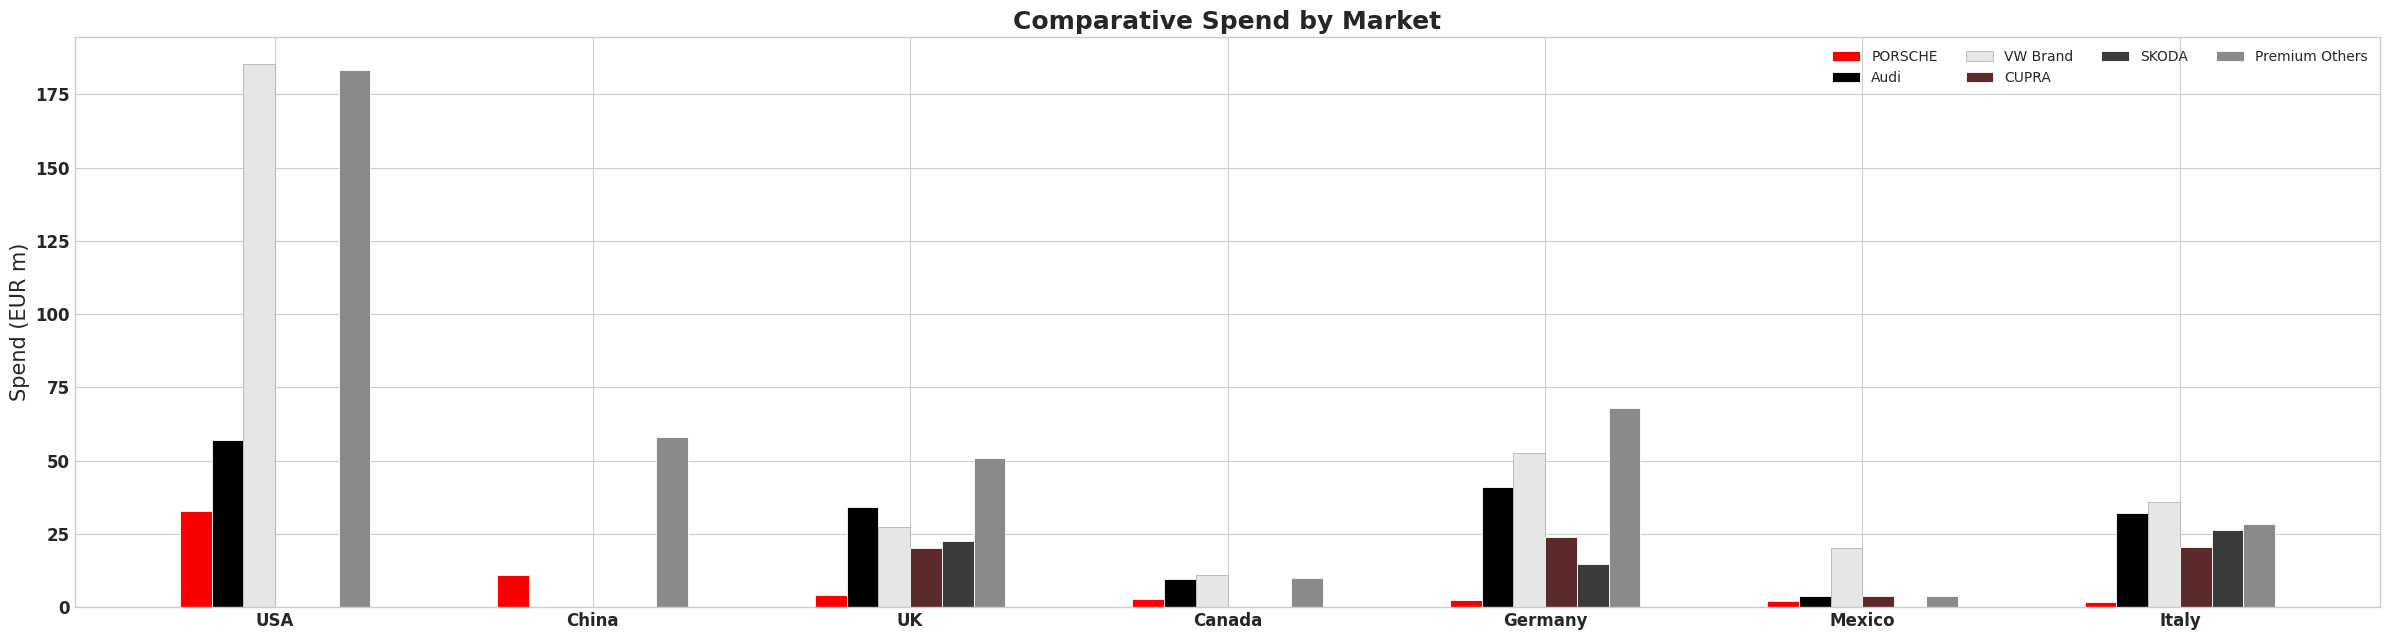

In [30]:
# 1) Spend by brand for selected markets on one chart (markets on X-axis)
#    Premium Others uses AVG (JLR vs Mercedes) by market, per request.
selected_markets = (
    df[df['brand'] == 'PORSCHE']
    .groupby('market', as_index=False)['spend_eur']
    .sum()
    .sort_values('spend_eur', ascending=False)
    .head(7)['market']
    .tolist()
)

# VW brands from combined df (already EUR). Omit Bentley here: in Mappe1 its spend is
# booked under "Bentley Central Campaigns", not under country markets, so geo bars would be misleading.
market_brand_vwg = (
    df[(df['market'].isin(selected_markets)) & (df['brand'] != 'Premium Others') & (df['brand'] != 'Bentley')]
    .groupby(['market', 'brand'], as_index=False)['spend_eur']
    .sum()
)

# Premium Others from dedicated AVG table (already EUR)
market_brand_premium = prem_avg_market[prem_avg_market['market'].isin(selected_markets)].copy()

market_brand = pd.concat([market_brand_vwg, market_brand_premium], ignore_index=True)
mat = market_brand.pivot(index='market', columns='brand', values='spend_eur').fillna(0)

# keep only requested markets present in data
present_markets = [m for m in selected_markets if m in mat.index]
mat = mat.reindex(present_markets)

# fixed brand order (no Bentley on this geo chart — see note above)
brand_order = ['PORSCHE', 'Audi', 'VW Brand', 'CUPRA', 'SKODA', 'Premium Others']
mat = mat.reindex(columns=brand_order, fill_value=0) / 1e6

# balanced spacing between markets + clearer bar separation
x = np.arange(len(mat.index)) * 0.85
n = len(mat.columns)
width = min(0.82 / max(n, 1), 0.085)

color_map = {
    'PORSCHE': '#f80000',
    'Audi': '#000000',
    'VW Brand': '#e6e6e6',
    'CUPRA': '#5c2a2a',
    'SKODA': '#3a3a3a',
    'Premium Others': '#8a8a8a',
}

fig, ax = plt.subplots(figsize=(24, 6.5))
for i, b in enumerate(mat.columns):
    off = (i - (n - 1) / 2) * width
    ec = '#b3b3b3' if b == 'VW Brand' else 'white'
    ax.bar(x + off, mat[b].values, width=width, label=b, color=color_map.get(b, '#6b7280'), edgecolor=ec, linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(mat.index, fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
for lbl in ax.get_yticklabels():
    lbl.set_fontweight('bold')
ax.set_ylabel('Spend (EUR m)', fontsize=15)
ax.set_title('Comparative Spend by Market', fontsize=18, fontweight='bold')
ax.legend(frameon=False, ncol=4, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

In [31]:
mat

brand,PORSCHE,Audi,VW Brand,CUPRA,SKODA,Premium Others
market,,,,,,
USA,32.848461,57.102987,185.158728,0.000000,0.000000,183.208873
China,10.800742,0.000000,0.000000,0.000000,0.000000,57.982350
UK,4.069785,34.087044,27.338235,20.348206,22.672134,50.724857
Canada,2.633829,9.695647,11.009053,0.000000,0.000000,9.954684
Germany,2.384298,40.864558,52.726566,23.776253,14.807280,67.973080
Mexico,2.171933,3.658532,20.290226,3.917636,0.000000,3.733481
Italy,1.919755,32.046285,35.887971,20.372299,26.448367,28.234381


In [32]:
# FORMAT ANALYSIS NOTES - SAMPLE CHARTS (sample_split_by_channel.png / sample_split_by_funnel.png)
#
# -----------------------------------------------------------------------------
# 1) sample_split_by_channel.png
# -----------------------------------------------------------------------------
# Canvas / layout
# - Image size: 1600 x 900 (16:9)
# - Background: very light gray (#F0F0F0-ish), not pure white
# - Hierarchy:
#   1) Big all-caps headline at top-left
#   2) Smaller subtitle directly below headline
#   3) Mid title centered: "GLOBAL: BY CHANNEL SPEND %"
#   4) Main chart area: two horizontal 100% stacked bars
#   5) Legend centered at bottom in one line
#
# Plot type
# - Horizontal 100% stacked bar chart with 2 groups:
#   - Other Brands
#   - Porsche
# - X-axis: 0% -> 100% in 10% increments
# - Vertical guide gridlines only (light gray)
# - No box frame around chart
#
# Channel categories used (from legend)
# - TV
# - Social
# - Digital I/O
# - Search
# - OOH
# - Programmatic Display
# - Programmatic Video
# - Print
# - Other
# - Radio
# - Cinema
# - Unallocated
#
# Color system (approx, sampled dominant palette)
# - Search: bright red (~#F80000)
# - Social: cyan-blue (~#0898D0)
# - Digital I/O: green (~#48A028)
# - TV: golden yellow (~#F8C000)
# - OOH: dark blue (~#085880)
# - Programmatic Display: magenta/lilac (~#D868C8)
# - Programmatic Video: black (~#000000)
# - Print: yellow (~#F8F800)
# - Other: light green (~#68C840)
# - Minor categories include orange/blue/green accents
#
# Text style (visual estimate)
# - Main headline: dark charcoal, uppercase, very large, medium-bold
# - Subtitle: smaller, uppercase, dark gray
# - Mid title: medium-large, gray, uppercase
# - Axis labels/ticks: medium gray, clean sans-serif
# - In-bar values: dark gray/black, centered
#
# -----------------------------------------------------------------------------
# 2) sample_split_by_funnel.png
# -----------------------------------------------------------------------------
# Canvas / layout
# - Image size: 1600 x 900 (16:9)
# - Same light gray background
# - Hierarchy:
#   1) Big all-caps headline at top-left
#   2) Center title: "FUNNEL SPLIT BENCHMARKS"
#   3) Main chart: two vertical stacked 100% columns
#   4) Compact legend below chart
#   5) Source note bottom-left
#
# Plot type
# - Vertical stacked 100% bar chart (2 columns):
#   - OTHER BRANDS
#   - PORSCHE
# - Y-axis: 0% -> 100% in 10% increments
# - Horizontal gridlines only
# - Value labels inside each stacked block
#
# Funnel stages + colors
# - LOWER: red (~#F80000)
# - MIDDLE: very light gray (~#E6E6E6)
# - UPPER: black (~#000000)
#
# Text style (visual estimate)
# - Headline: same style as channel sample
# - Secondary title: medium gray, uppercase
# - Axis labels/ticks: mid-gray
# - Data labels: dark text on light blocks, white text on black block
# - Source line: small dark-gray text at bottom-left
#
# -----------------------------------------------------------------------------
# Cross-sample style principles to reuse
# -----------------------------------------------------------------------------
# - Calm light-gray background
# - Strong uppercase narrative headline
# - Simple, high-contrast color semantics
# - Minimal clutter (few chart elements, no heavy borders)
# - Clear legend + direct data labels where possible
# - Consistent typographic scale and spacing


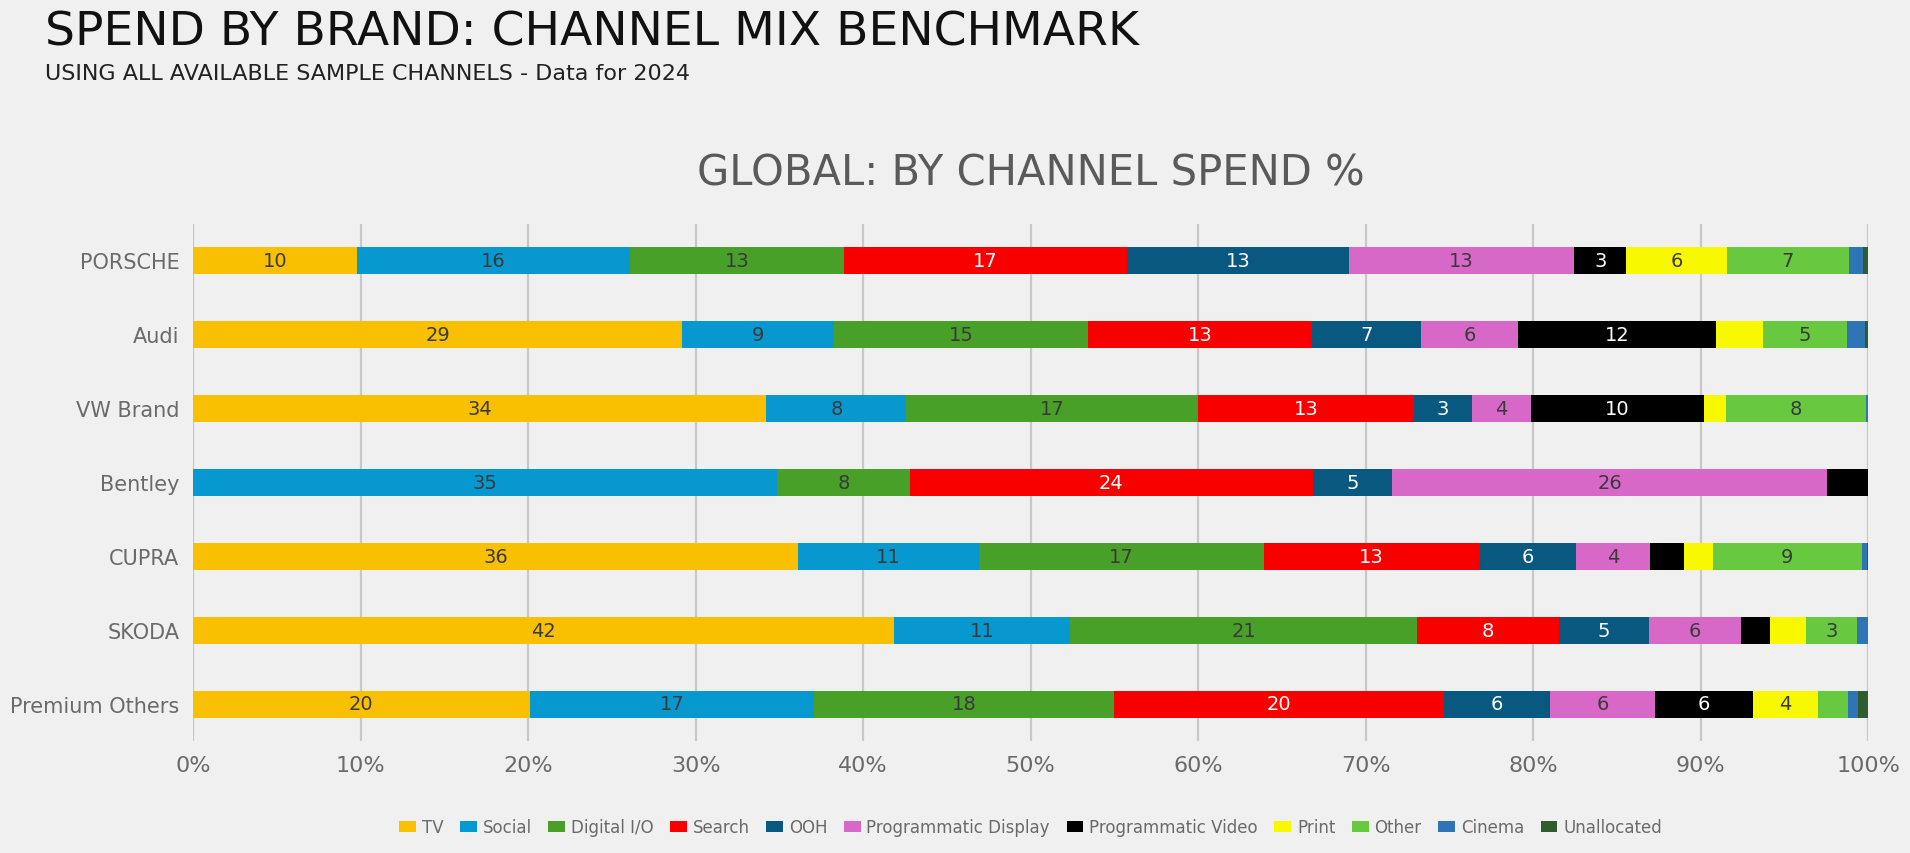

Channels used in this chart: ['TV', 'Social', 'Digital I/O', 'Search', 'OOH', 'Programmatic Display', 'Programmatic Video', 'Print', 'Other', 'Cinema', 'Unallocated']


In [33]:
# 2B) Sample-style replica: spend by brand using all available sample channels
#     (100% stacked horizontal bars, matching sample_split_by_channel format)

sample_channel_order = [
    'TV', 'Social', 'Digital I/O', 'Search', 'OOH', 'Programmatic Display',
    'Programmatic Video', 'Print', 'Other', 'Radio', 'Cinema', 'Unallocated'
]

# Map raw media labels to sample-style channel buckets
ch = df.copy()
raw = ch['channel'].fillna('').astype(str)
low = raw.str.lower().str.strip()

ch['channel_sample'] = np.select(
    [
        low.str.contains(r'\btv\b|connected tv|ctv', regex=True),
        low.str.contains(r'social|facebook|instagram|meta|tiktok|linkedin|pinterest|snapchat|x\b|twitter', regex=True),
        low.str.contains(r'digital i/o|digital io|io\b', regex=True),
        low.str.contains(r'search|sem|sea|google ads|bing', regex=True),
        low.str.contains(r'\booh\b|out[- ]?of[- ]?home|dooh', regex=True),
        low.str.contains(r'programmatic display', regex=True),
        low.str.contains(r'programmatic video|dig\.? video|digital video', regex=True),
        low.str.contains(r'print', regex=True),
        low.str.contains(r'other|misc|unknown', regex=True),
        low.str.contains(r'radio|audio', regex=True),
        low.str.contains(r'cinema', regex=True),
        low.str.contains(r'unallocated|not allocated|n/a', regex=True),
    ],
    [
        'TV', 'Social', 'Digital I/O', 'Search', 'OOH', 'Programmatic Display',
        'Programmatic Video', 'Print', 'Other', 'Radio', 'Cinema', 'Unallocated'
    ],
    default='__UNMAPPED__'
)

# keep only channels that are both in sample-style list and present in data
present_channels = [c for c in sample_channel_order if c in set(ch['channel_sample'].dropna())]
plot_df = ch[ch['channel_sample'].isin(present_channels)].copy()

# aggregate to % split by brand
# Premium Others here is SUM of JLR + Mercedes (as requested for this plot)
brand_order = ['PORSCHE', 'Audi', 'VW Brand', 'Bentley', 'CUPRA', 'SKODA', 'Premium Others']
mat = (
    plot_df.groupby(['brand', 'channel_sample'], as_index=False)['spend_eur'].sum()
    .pivot(index='brand', columns='channel_sample', values='spend_eur')
    .reindex(index=brand_order)
    .reindex(columns=present_channels)
    .fillna(0)
)
mat_pct = mat.div(mat.sum(axis=1).replace(0, np.nan), axis=0) * 100
mat_pct = mat_pct.fillna(0)

# sample-like palette (approx from sample image)
channel_colors = {
    'TV': '#f8c000',
    'Social': '#0898d0',
    'Digital I/O': '#48a028',
    'Search': '#f80000',
    'OOH': '#085880',
    'Programmatic Display': '#d868c8',
    'Programmatic Video': '#000000',
    'Print': '#f8f800',
    'Other': '#68c840',
    'Radio': '#c06000',
    'Cinema': '#2f75b5',
    'Unallocated': '#2f5d2f',
}

# --- Plot (match sample style) ---
fig, ax = plt.subplots(figsize=(20, 10.5), facecolor='#f0f0f0')
ax.set_facecolor('#f0f0f0')

y = np.arange(len(mat_pct.index))
left = np.zeros(len(mat_pct.index))

for c in present_channels:
    vals = mat_pct[c].values
    bars = ax.barh(
        y, vals, left=left, height=0.36,
        color=channel_colors.get(c, '#bbbbbb'),
        edgecolor='none', label=c
    )
    # in-segment labels (only where readable)
    for i, (b, v) in enumerate(zip(bars, vals)):
        if v >= 3:
            txt_color = 'white' if c in ['OOH', 'Programmatic Video', 'Search'] else '#3a3a3a'
            ax.text(left[i] + v / 2, b.get_y() + b.get_height() / 2, f'{int(round(v))}',
                    ha='center', va='center', fontsize=14, color=txt_color)
    left += vals

# Axes, ticks, gridlines
ax.set_yticks(y)
ax.set_yticklabels(mat_pct.index, fontsize=15, color='#6a6a6a')
ax.invert_yaxis()  # keep top-to-bottom brand order consistent with sample feel
ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 10))
ax.set_xticklabels([f'{t}%' for t in range(0, 101, 10)], fontsize=16, color='#6a6a6a')
ax.tick_params(axis='both', length=0, pad=10)
ax.grid(axis='x', color='#c8c8c8', linewidth=1.6)
ax.set_axisbelow(True)
for s in ['top', 'right', 'left', 'bottom']:
    ax.spines[s].set_visible(False)

# Titles (sample hierarchy)
fig.text(0.055, 0.94, 'SPEND BY BRAND: CHANNEL MIX BENCHMARK',
         fontsize=34, color='#111111', ha='left', va='center')
fig.text(0.055, 0.90,
         'USING ALL AVAILABLE SAMPLE CHANNELS - Data for 2024',
         fontsize=16, color='#222222', ha='left', va='center')
ax.set_title('GLOBAL: BY CHANNEL SPEND %', fontsize=30, color='#5a5a5a', pad=28)

# Legend at bottom, one row where possible
leg = ax.legend(
    ncol=min(len(present_channels), 12),
    loc='upper center', bbox_to_anchor=(0.5, -0.12),
    frameon=False, fontsize=12, handlelength=1.0, handletextpad=0.35, columnspacing=1.0
)
for t in leg.get_texts():
    t.set_color('#6a6a6a')

plt.tight_layout(rect=[0.03, 0.12, 0.99, 0.84])
plt.show()

print('Channels used in this chart:', present_channels)


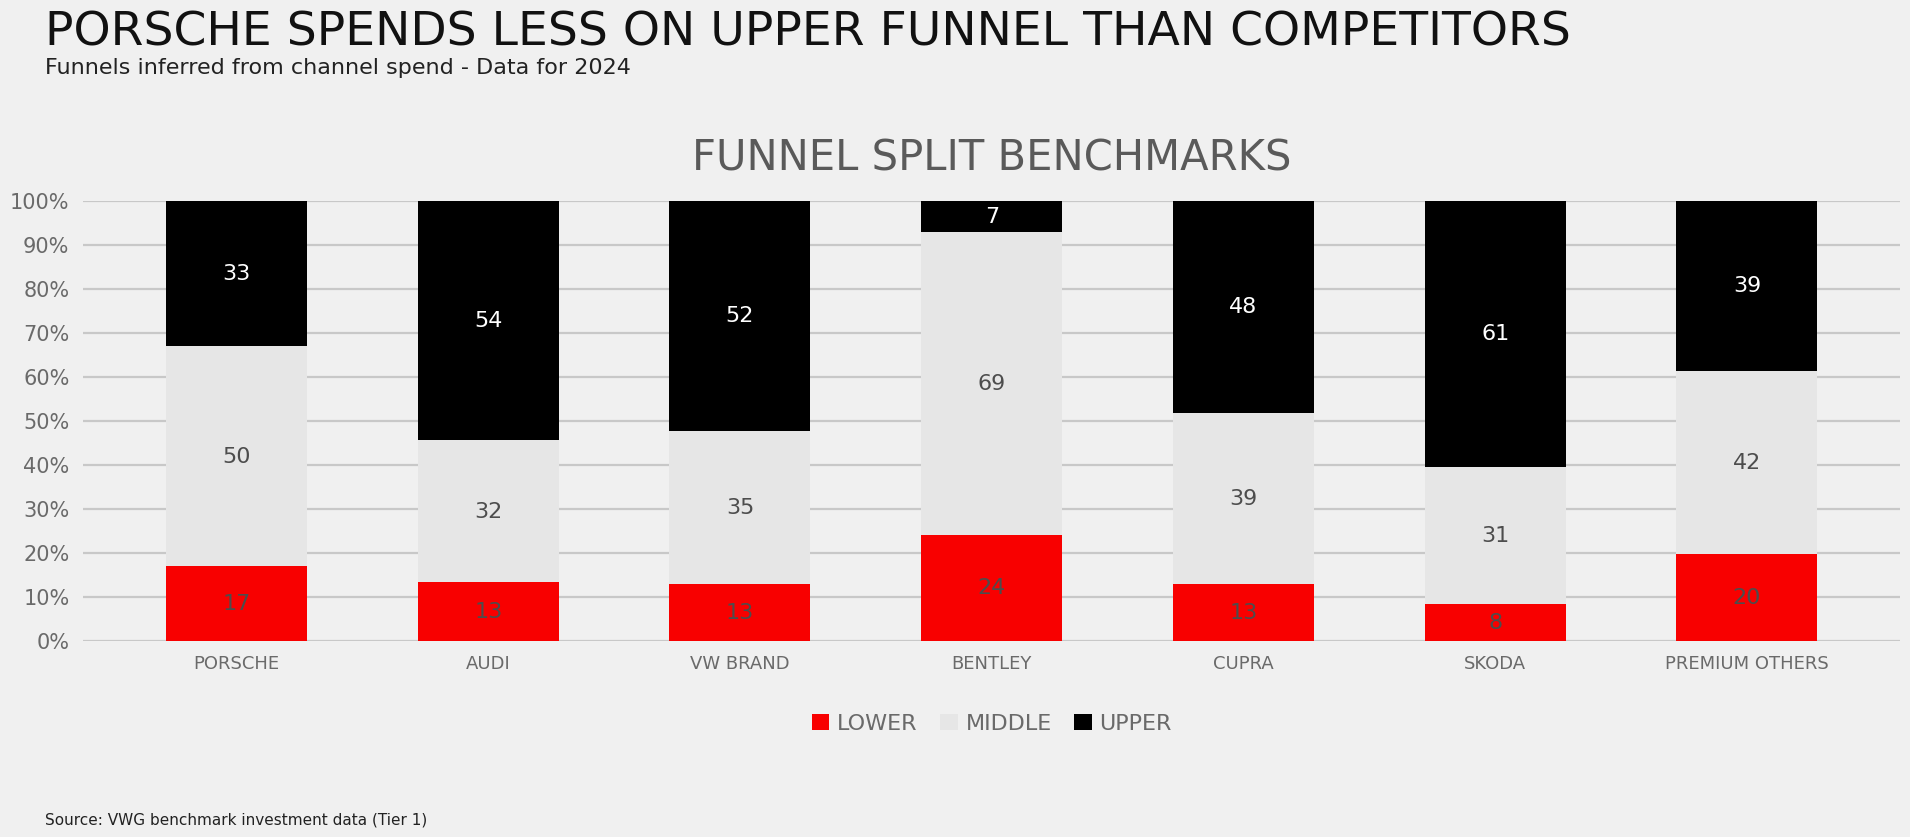

In [34]:
# 3B) Sample-style replica: spend by brand for each funnel stage
#     (matches sample_split_by_funnel style: 100% stacked vertical bars)

# Premium Others here is SUM of JLR + Mercedes (as requested for this plot)
brand_order = ['PORSCHE', 'Audi', 'VW Brand', 'Bentley', 'CUPRA', 'SKODA', 'Premium Others']
stage_order = ['LOWER', 'MIDDLE', 'UPPER']

# Aggregate spend by brand x funnel stage and convert to within-brand % split
stage_brand = (
    df[df['brand'].isin(brand_order)]
    .groupby(['brand', 'funnel_stage'], as_index=False)['spend_eur']
    .sum()
)

mat = (
    stage_brand.pivot(index='brand', columns='funnel_stage', values='spend_eur')
    .reindex(index=brand_order)
    .reindex(columns=stage_order)
    .fillna(0)
)
mat_pct = mat.div(mat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100

# Funnel palette from sample_split_by_funnel
funnel_colors = {
    'LOWER': '#f80000',   # red
    'MIDDLE': '#e6e6e6',  # light gray
    'UPPER': '#000000',   # black
}

fig, ax = plt.subplots(figsize=(20, 9), facecolor='#f0f0f0')
ax.set_facecolor('#f0f0f0')

x = np.arange(len(mat_pct.index))
width = 0.56
bottom = np.zeros(len(mat_pct.index))

for st in stage_order:
    vals = mat_pct[st].values
    bars = ax.bar(
        x, vals, width=width, bottom=bottom,
        color=funnel_colors[st], edgecolor='none', label=st
    )

    # segment value labels (sample-like)
    for i, (b, v) in enumerate(zip(bars, vals)):
        if v >= 4:
            txt_color = 'white' if st == 'UPPER' else '#4d4d4d'
            ax.text(
                b.get_x() + b.get_width() / 2,
                bottom[i] + v / 2,
                f'{int(round(v))}',
                ha='center', va='center', fontsize=16, color=txt_color
            )
    bottom += vals

# Axes/grid to match sample
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 10))
ax.set_yticklabels([f'{t}%' for t in range(0, 101, 10)], fontsize=15, color='#6a6a6a')
ax.set_xticks(x)
ax.set_xticklabels([b.upper() for b in mat_pct.index], fontsize=13, color='#6a6a6a')
ax.grid(axis='y', color='#c8c8c8', linewidth=1.6)
ax.set_axisbelow(True)
ax.tick_params(axis='both', length=0, pad=10)
for s in ['top', 'right', 'left', 'bottom']:
    ax.spines[s].set_visible(False)

# Titles + source line (same hierarchy as sample)
fig.text(0.055, 0.94, 'PORSCHE SPENDS LESS ON UPPER FUNNEL THAN COMPETITORS',
         fontsize=34, color='#111111', ha='left', va='center')
ax.set_title('FUNNEL SPLIT BENCHMARKS', fontsize=30, color='#5a5a5a', pad=22)

# Legend below plot, compact
leg = ax.legend(
    ncol=3,
    loc='upper center', bbox_to_anchor=(0.5, -0.12),
    frameon=False, fontsize=16, handlelength=0.8, handletextpad=0.35, columnspacing=1.0
)
for t in leg.get_texts():
    t.set_color('#6a6a6a')
fig.text(0.055, 0.90,
         'Funnels inferred from channel spend - Data for 2024',
         fontsize=16, color='#222222', ha='left', va='center')
fig.text(0.055, 0.06, 'Source: VWG benchmark investment data (Tier 1)',
         fontsize=11, color='#222222', ha='left')

plt.tight_layout(rect=[0.03, 0.10, 0.99, 0.84])
plt.show()
